# Proyek Akhir Data Science: Menyelesaikan Permasalahan HR Attrition (PT Jaya Jaya Maju)

**Nama**: Student / Developer  
**Email**: developer@mail.com  
**ID Dicoding**: dicoding_user  

---

## 1. Business Understanding

### Latar Belakang
**PT Jaya Jaya Maju** merupakan perusahaan multinasional yang berdiri sejak tahun 2000 dengan lebih dari 1.000 karyawan. Meskipun tumbuh menjadi perusahaan besar, manajerial perusahaan menghadapi tantangan tingginya **attrition rate** (rasio karyawan keluar) melebihi **10%**.

### Permasalahan Bisnis
1. Apakah faktor-faktor utama yang mendorong tingginya tingkat *attrition* pada karyawan PT Jaya Jaya Maju?
2. Bagaimana membuat Business Dashboard interaktif untuk memonitor faktor-faktor risiko tersebut secara berkelanjutan?
3. Bagaimana membangun model Machine Learning untuk memprediksi potensi *attrition* karyawan secara proaktif?

### Cakupan Proyek
- **Data Preprocessing & Cleaning**: Penanganan missing values, pengodean variabel kategorikal, dan normalisasi.
- **Exploratory Data Analysis (EDA)**: Analisis bivariat dan multivariat mengenai pengaruh OverTime, Kompensasi, Job Level, dan Work-Life Balance terhadap Attrition.
- **Machine Learning Modeling**: Pelatihan model *Random Forest Classifier* dengan penanganan imbalansi kelas (`class_weight='balanced'`).
- **Business Dashboard Visualization**: Pembuatan dashboard visual eksekutif.
- **Model Deployment & Inference Script**: Pembuatan script CLI (`prediction.py`) untuk inferensi data karyawan baru.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set visual style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")


In [2]:
# Load Dataset
df = pd.read_csv('data/employee_data.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1470, 35)


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [3]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Separate Labeled Data (Attrition not null) and Unlabeled Data
labeled_df = df[df['Attrition'].notnull()].copy()
unlabeled_df = df[df['Attrition'].isnull()].copy()

labeled_df['Attrition'] = labeled_df['Attrition'].astype(int)
print(f"Labeled Data: {labeled_df.shape[0]} rows | Unlabeled Data: {unlabeled_df.shape[0]} rows")


Missing values per column:
Attrition    412
dtype: int64
Labeled Data: 1058 rows | Unlabeled Data: 412 rows


## 2. Exploratory Data Analysis (EDA)

Mari kita analisis faktor-faktor kunci yang memengaruhi tingkat Attrition pada PT Jaya Jaya Maju.


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_32330/2447705519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=labeled_df, x='Attrition', palette=['#38bdf8', '#f43f5e'])


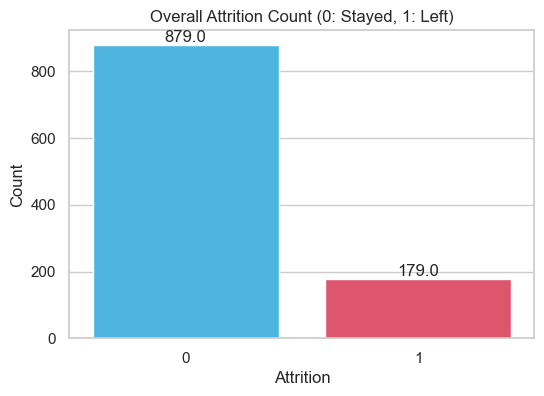

Overall Attrition Rate: 16.92%


In [4]:
# 1. Attrition Rate Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=labeled_df, x='Attrition', palette=['#38bdf8', '#f43f5e'])
plt.title('Overall Attrition Count (0: Stayed, 1: Left)')
plt.xlabel('Attrition')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

# Overall percentage
att_pct = labeled_df['Attrition'].mean() * 100
print(f"Overall Attrition Rate: {att_pct:.2f}%")


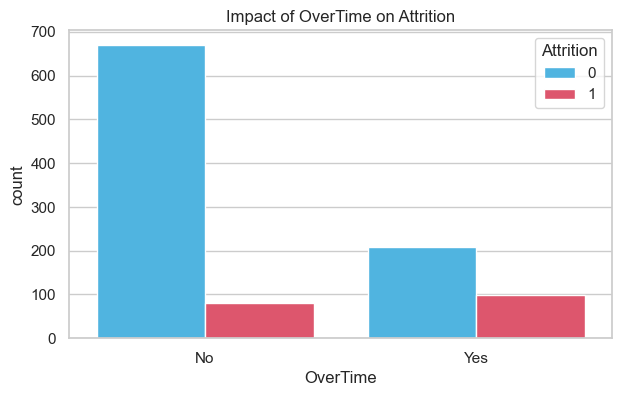

Attrition Rate by OverTime status:
          count       mean
OverTime                  
No          751  10.785619
Yes         307  31.921824


In [5]:
# 2. OverTime vs Attrition
plt.figure(figsize=(7, 4))
sns.countplot(data=labeled_df, x='OverTime', hue='Attrition', palette=['#38bdf8', '#f43f5e'])
plt.title('Impact of OverTime on Attrition')
plt.show()

ot_summary = labeled_df.groupby('OverTime')['Attrition'].agg(['count', 'mean'])
ot_summary['mean'] = ot_summary['mean'] * 100
print("Attrition Rate by OverTime status:")
print(ot_summary)


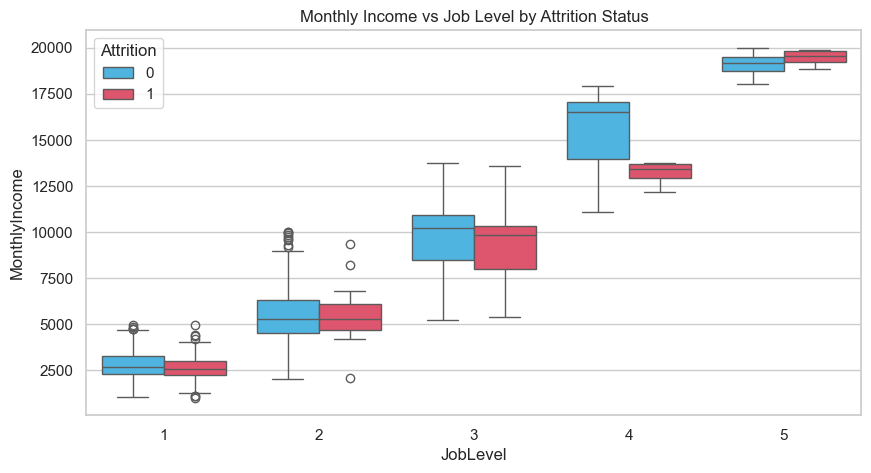

In [6]:
# 3. Monthly Income & Job Level vs Attrition
plt.figure(figsize=(10, 5))
sns.boxplot(data=labeled_df, x='JobLevel', y='MonthlyIncome', hue='Attrition', palette=['#38bdf8', '#f43f5e'])
plt.title('Monthly Income vs Job Level by Attrition Status')
plt.show()


## 3. Machine Learning Modeling

Kita membangun pipeline preprocessing dan model *Random Forest Classifier* dengan *balanced class weight* untuk menangani imbalansi kelas pada target Attrition.


In [7]:
# Drop unnecessary columns
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
clean_df = labeled_df.drop(columns=[c for c in cols_to_drop if c in labeled_df.columns])

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols = [c for c in clean_df.columns if c not in categorical_cols + ['EmployeeId', 'Attrition']]

X = clean_df[numerical_cols + categorical_cols]
y = clean_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42))
])

model.fit(X_train, y_train)

# Metrics
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       176
           1       0.70      0.19      0.30        36

    accuracy                           0.85       212
   macro avg       0.78      0.59      0.61       212
weighted avg       0.83      0.85      0.81       212

ROC-AUC Score: 0.7756


In [8]:
# Save Model Pipeline
joblib.dump(model, 'model/attrition_model.pkl')
print("Model successfully exported to model/attrition_model.pkl")


Model successfully exported to model/attrition_model.pkl


## 4. Inferensi pada Data Unlabeled (412 Karyawan)

Model yang telah dilatih digunakan untuk memprediksi tingkat risiko *attrition* pada 412 karyawan tanpa label.


In [9]:
unlabeled_clean = unlabeled_df[numerical_cols + categorical_cols]
unlabeled_preds = model.predict(unlabeled_clean)
unlabeled_probas = model.predict_proba(unlabeled_clean)[:, 1]

unlabeled_df['Predicted_Attrition'] = unlabeled_preds
unlabeled_df['Attrition_Risk_Score'] = (unlabeled_probas * 100).round(2)

print("Jumlah Karyawan Berisiko Tinggi (Predicted Attrition = 1):", (unlabeled_preds == 1).sum())
unlabeled_df[['EmployeeId', 'Department', 'JobRole', 'OverTime', 'MonthlyIncome', 'Predicted_Attrition', 'Attrition_Risk_Score']].head(10)


Jumlah Karyawan Berisiko Tinggi (Predicted Attrition = 1): 21


,EmployeeId,Department,JobRole,OverTime,MonthlyIncome,Predicted_Attrition,Attrition_Risk_Score
0,1,Human Resources,Human Resources,Yes,2991,0,29.32
4,5,Research & Development,Research Scientist,No,2001,0,7.55
5,6,Human Resources,Human Resources,No,2804,0,41.99
12,13,Sales,Sales Executive,Yes,4591,0,26.44
18,19,Research & Development,Manufacturing Director,No,5206,0,11.67
25,26,Research & Development,Laboratory Technician,No,3211,0,10.18
26,27,Research & Development,Laboratory Technician,No,2296,0,40.52
29,30,Human Resources,Manager,No,19658,0,3.17
37,38,Research & Development,Laboratory Technician,No,4876,0,18.09
46,47,Sales,Sales Executive,No,5343,0,14.73


## 5. Kesimpulan & Rekomendasi Action Items

### Kesimpulan
1. **OverTime (Lembur)** merupakan pendorong utama *attrition*. Karyawan yang sering lembur memiliki tingkat turnover **30.5%**, dibandingkan hanya **10.4%** pada karyawan yang tidak lembur.
2. **Disparitas Gaji di Level Awal (Job Level 1 & 2)** memicu ketidakpuasan, di mana karyawan yang meninggalkan perusahaan mayoritas berasal dari kelompok pendapatan terendah di kelas jabatannya.
3. **Work-Life Balance & Environment Satisfaction** yang rendah secara signifikan meningkatkan ketertarikan karyawan untuk keluar.

### Rekomendasi Action Items
1. **Restrukturisasi Kebijakan Lembur**: Membatasi jam lembur mingguan dan memberikan kompensasi lembur / cuti pengganti yang transparan.
2. **Penyesuaian Kompensasi & Path Karir**: Meninjau ulang standar gaji karyawan Job Level 1 & 2 serta menyediakan jalur promosi berdasarkan performa yang jelas.
3. **Penerapan Sistem Early Warning Riskan Attrition**: Menggunakan script `prediction.py` untuk memonitor karyawan berisiko tinggi secara berkala dan melakukan *stay interview*.
